# P1: O‘zbek NLP — matnni qayta ishlash laboratoriyasi


**Mavzu:** o‘zbek tili uchun tokenizatsiya, stopword filtrlash, stemming, So‘zlar xaltasi (BoW) va TF-IDF  
**Ma’ruza bilan bog‘lanish:** 1-ma’ruza — NLP asoslari va matnni qayta ishlash  
**Asosiy artefakt:** `capstone/modules/m01_text_preprocessor.py`  
**Platforma:** Google Colab, Kaggle Notebook yoki lokal Jupyter. Notebook o‘z-o‘zini ta’minlaydi; `uz_news_mini.txt` topilsa undan foydalanadi, topilmasa ichki fallback korpus yaratadi.

**Amaliyot uslubi:** Taxmin qiling → Ishga tushiring → Kuzating → O‘zgartiring → assert bilan tekshiring.

> Talaba versiyasida **TO‘LDIRING** joylari ataylab bo‘sh qoldirilgan.  
> O‘qituvchi yechimida barcha TO‘LDIRING qismlari to‘ldirilgan va notebook boshidan oxirigacha ishlaydi.


In [15]:
from pathlib import Path
import shutil

ASSET_SRC = Path("/kaggle/input/datasets/khilolakhushmanova/my-asset-p2")
ASSET_DST = Path("assets/d02")
ASSET_DST.mkdir(parents=True, exist_ok=True)

expected = [
    "d02_destination.png",
    "d02_pipeline.png",
    "d02_unicode_apostrophes.png",
    "d02_bow_matrix.png",
    "d02_tfidf_concept.png",
    "d02_capstone_wrapper.png",
]

print("Asset source:", ASSET_SRC)
print("Asset destination:", ASSET_DST.resolve())
print()

if not ASSET_SRC.exists():
    print("ERROR: source folder not found.")
    print("Replace YOUR_DATASET_SLUG with your real Kaggle dataset slug.")
else:
    copied = []
    missing = []

    for name in expected:
        src = ASSET_SRC / name
        dst = ASSET_DST / name

        if src.exists():
            shutil.copy(src, dst)
            copied.append(name)
            print(f"COPIED: {name} -> {dst}")
        else:
            missing.append(name)
            print(f"MISSING: {src}")

    print()
    print(f"Copied {len(copied)} / {len(expected)} files.")

    if missing:
        print("Missing files:", missing)
    else:
        print("All visual assets are ready.")


Asset source: /kaggle/input/datasets/khilolakhushmanova/my-asset-p2
Asset destination: /kaggle/working/assets/d02

COPIED: d02_destination.png -> assets/d02/d02_destination.png
COPIED: d02_pipeline.png -> assets/d02/d02_pipeline.png
COPIED: d02_unicode_apostrophes.png -> assets/d02/d02_unicode_apostrophes.png
COPIED: d02_bow_matrix.png -> assets/d02/d02_bow_matrix.png
COPIED: d02_tfidf_concept.png -> assets/d02/d02_tfidf_concept.png
COPIED: d02_capstone_wrapper.png -> assets/d02/d02_capstone_wrapper.png

Copied 6 / 6 files.
All visual assets are ready.


In [14]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/khilolakhushmanova
/kaggle/input/datasets/khilolakhushmanova/my-asset-p2


## 80 daqiqalik amaliyot rejasi

| Vaqt | Bo‘lim | Talaba nima qiladi | Tekshiruv nuqtasi |
|---:|---|---|---|
| 0–6 daq | Korpus va motivatsiya | `uz_news_mini.txt` bilan tanishadi, keyword sentiment xatosini ko‘radi | Korpus nima ekanini tushuntiradi |
| 6–16 daq | Pipeline ko‘rinishi | Xom matndan vektorgacha xaritani ko‘radi | Har bosqichni nomlaydi |
| 16–33 daq | O‘zbek tokenizatsiyasi | Apostrof variantlarini tekshiradi | `uz_tokenize()` assertlardan o‘tadi |
| 33–50 daq | Stopword filtrlash + stemming | Asosiy preprocessing funksiyalarini to‘ldiradi | `preprocess_doc()` assertlardan o‘tadi |
| 50–65 daq | BoW + TF-IDF | 3 hujjatli korpusda matritsalarni qo‘lda quradi | Ma’ruzadagi qiymatlar mos keladi |
| 65–73 daq | Real korpus vectorization | `uz_news_mini.txt` uchun BoW/TF-IDF matritsa quradi | Matritsa shakli va top tokenlarni izohlaydi |
| 73–78 daq | Yakuniy loyiha moduli | `m01_text_preprocessor.py` faylini saqlaydi | Modul import qilinadi va testdan o‘tadi |
| 78–80 daq | Chiqish bileti | Dizayn qarorini tushuntiradi | 3–5 gapli javob |


## Ishlatiladigan kutubxonalar

Bu lab uchun og'ir model kutubxonalari kerak emas. Har bir paketning roli aniq:

- `pathlib` — Kaggle/local fayl yo'llarini topish;
- `re` — apostrofli o'zbek tokenlari uchun regex;
- `math` / `numpy` — TF-IDF formulalari va matritsa tekshiruvlari;
- `pandas` — tokenlar va matritsalarni jadvalda ko'rsatish;
- `matplotlib` — lug'at hajmi, BoW matritsasi va TF-IDF top-so'zlarini chizish;
- `scikit-learn` — `CountVectorizer` va `TfidfVectorizer`.

Hugging Face bu darsda ishlatilmaydi; u keyingi dataset/model darslari uchun kerak bo'ladi.


## Nima quramiz?

Bugungi maqsad bitta oddiy, lekin qayta ishlatiladigan pipeline qurish:

`xom matn -> apostrof normallashtirish -> tokenizatsiya -> stopword filtrlash -> stemming -> BoW / TF-IDF`

Dars davomida har bir bosqichni alohida tekshiramiz. Muhim g'oya: model qurishdan oldin matnni bir xil, barqaror shaklga keltirish kerak.

![Bugungi yakuniy oqim](assets/d02/d02_destination.png)


In [16]:
# ============================================================
# 0. Sozlash — Kaggle va lokal Jupyterda ishlaydi
# ============================================================
from pathlib import Path
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 90)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

UZ_NEWS_MINI_FALLBACK = [
    "O'zbekiston iqtisodiyoti so'nggi yillarda barqaror rivojlanmoqda.",
    "Toshkent shahri mamlakatning madaniy va ilmiy markazi hisoblanadi.",
    "Sun'iy intellekt texnologiyalari dunyo bo'ylab keng tarqalmoqda.",
    "O'zbek tili agglyutinativ til bo'lib, so'zlarga ko'plab qo'shimchalar qo'shiladi.",
    "Tabiiy tilni qayta ishlash tizimlari o'zbek matni uchun yaratilmoqda.",
    "Dasturiy ta'minot sohasida o'zbek mutaxassislari faol ishlamoqda.",
    "Yangi texnologiyalar qishloq xo'jaligi samaradorligini oshirmoqda.",
    "Raqamli iqtisodiyotga o'tish davlatning asosiy ustuvorliklaridan biridir.",
    "Yoshlar ta'lim sohasiga katta e'tibor qaratmoqda.",
    "Matnlarni avtomatik tahlil qilish tizimlarini yaratish murakkab jarayondir.",
    "Internet foydalanuvchilari soni yil sayin ortib bormoqda.",
    "Ilm-fan va innovatsiyalar iqtisodiy o'sishning asosiy omillaridan hisoblanadi.",
    "Kompyuter lingvistikasi tillarga dasturlash nuqtai nazaridan yondashadi.",
    "O'zbek adabiyotida ko'plab buyuk asarlar yaratilgan va hali ham yaratilmoqda.",
    "Milliy tillarni raqamlashtirish zamonaviy davlatning muhim vazifalaridan biridir.",
    "Elektron tijorat platformalari mahsulot va xizmatlar sotishni osonlashtiradi.",
    "Ma'lumotlarni tahlil qilish biznes qarorlarini qabul qilishda yordam beradi.",
    "Kiberxavfsizlik masalalari barcha tashkilotlar uchun dolzarb muammodir.",
    "O'quv dasturlari zamonaviy ish bozori talablariga mos bo'lishi kerak.",
    "Barqaror rivojlanish maqsadlari insoniyatning kelajagi uchun muhim ahamiyat kasb etadi.",
]


def find_corpus_file() -> Path | None:
    names = ["uz_news_mini_v2.txt", "uz_news_mini.txt"]
    candidates = []
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for name in names:
            candidates.extend(kaggle_root.rglob(name))
    for name in names:
        candidates.extend([
            Path(name),
            Path("data") / name,
            Path("d02_checkpoints") / name,
            Path("practices/d02_checkpoints") / name,
            Path("../practices/d02_checkpoints") / name,
            Path("/mnt/data") / name,
        ])
    return next((p for p in candidates if p.exists()), None)

corpus_source = find_corpus_file()
if corpus_source is not None:
    RAW_TEXTS = [line.strip() for line in corpus_source.read_text(encoding="utf-8").splitlines() if line.strip()]
    source_name = str(corpus_source)
else:
    RAW_TEXTS = UZ_NEWS_MINI_FALLBACK
    source_name = "ichki fallback korpus"

corpus_file = DATA_DIR / "uz_news_mini.txt"
corpus_file.write_text("\n".join(RAW_TEXTS), encoding="utf-8")

DEMO_TEXTS = [
    "Uzum Market ilovasi juda qulay va tez ishlaydi.",
    "Yetkazib berish uch kun kechikdi, xizmat yomon.",
    "Mahsulot yaxshi emas, qaytarib bering.",
    "O'zbek NLP pipeline'i apostrofli so'zlarni to'g'ri ushlashi kerak.",
]

print(f"Manba: {source_name}")
print(f"Hujjatlar soni: {len(RAW_TEXTS)}")
print("Birinchi hujjat:", RAW_TEXTS[0])


Manba: /kaggle/input/datasets/khilolakhushmanova/uz-news-mini/uz_news_mini.txt
Hujjatlar soni: 20
Birinchi hujjat: O'zbekiston iqtisodiyoti so'nggi yillarda barqaror rivojlanmoqda.


In [18]:
# Run only: vizual yordamchi funksiyalar

def plot_vocab_change(raw_texts: list[str], processed_docs: list[list[str]]) -> None:
    raw_tokens = [tok.lower() for text in raw_texts for tok in text.split()]
    clean_tokens = [tok for doc in processed_docs for tok in doc]
    values = [len(set(raw_tokens)), len(set(clean_tokens))]
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    bars = ax.bar(["xom lug'at", "preprocessdan keyin"], values, color=["#4C78A8", "#F58518"])
    ax.set_ylabel("unikal tokenlar")
    ax.set_title("Preprocessing lug'at hajmini kamaytiradi")
    ax.bar_label(bars, padding=3)
    plt.show()


def plot_matrix_preview(matrix, title: str, max_rows: int = 8, max_cols: int = 16) -> None:
    arr = matrix[:max_rows, :max_cols].toarray() if hasattr(matrix, "toarray") else matrix[:max_rows, :max_cols]
    fig, ax = plt.subplots(figsize=(8, 3.4))
    im = ax.imshow(arr, aspect="auto", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("feature ustunlari")
    ax.set_ylabel("hujjatlar")
    fig.colorbar(im, ax=ax, fraction=0.03)
    plt.show()


def plot_top_terms(terms, weights, title: str, top_n: int = 8) -> None:
    terms = np.asarray(terms)
    weights = np.asarray(weights)
    top_idx = weights.argsort()[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.barh(terms[top_idx][::-1], weights[top_idx][::-1], color="#54A24B")
    ax.set_title(title)
    ax.set_xlabel("vazn")
    plt.show()


## 0A. Korpus bilan tanishish

Bu versiyada asosiy amaliy korpus sifatida `uz_news_mini.txt` ishlatiladi. Har bir satr — alohida hujjat. Korpus kichik, lekin O‘zbek NLP uchun kerakli hodisalarni ko‘rsatadi: apostrofli so‘zlar (`O'zbek`, `ta'minot`, `ma'lumot`), qo‘shimchalar, ko‘p takrorlanadigan umumiy so‘zlar va mavzuga xos terminlar.

Qo‘lda hisoblash uchun 3 hujjatli juda kichik korpus ham qoladi: `nlp qiziq`, `python foydali`, `nlp foydali`. Bu ma’ruzadagi TF-IDF assertlarini aniq tekshirish uchun kerak.


In [20]:
# Korpusning birinchi 5 hujjatini ko'ramiz
pd.DataFrame({
    "id": [f"D{i+1}" for i in range(len(RAW_TEXTS))],
    "matn": RAW_TEXTS,
}).head(5)

,id,matn
0,D1,O'zbekiston iqtisodiyoti so'nggi yillarda barqaror rivojlanmoqda.
1,D2,Toshkent shahri mamlakatning madaniy va ilmiy markazi hisoblanadi.
2,D3,Sun'iy intellekt texnologiyalari dunyo bo'ylab keng tarqalmoqda.
3,D4,"O'zbek tili agglyutinativ til bo'lib, so'zlarga ko'plab qo'shimchalar qo'shiladi."
4,D5,Tabiiy tilni qayta ishlash tizimlari o'zbek matni uchun yaratilmoqda.


## 1. Motivatsiya: xom keyword yetarli emas

Sodda sentiment qoidasi shunday bo‘lishi mumkin: “agar `yaxshi` so‘zi bo‘lsa, sharh ijobiy”.  
Lekin `yaxshi emas` kabi inkor ifodalarida bu qoida xato qiladi.

**Ishga tushirishdan oldin taxmin qiling:** quyidagi qaysi sharhni sodda klassifikator noto‘g‘ri belgilaydi?


In [22]:
def sodda_sentiment(sharh: str) -> str:
    """Juda sodda qoida: ijobiy so'z bo'lsa, sharh ijobiy deb olinadi."""
    sharh = sharh.lower()
    if "yaxshi" in sharh or "zo'r" in sharh or "qulay" in sharh:
        return "ijobiy"
    return "salbiy"

sharhlar = [
    "Bu mahsulot yaxshi va qulay.",
    "Bu mahsulot yaxshi emas, qaytarib bering!",
    "Yetkazib berish kechikdi.",
]

for sharh in sharhlar:
    print(f"{sharh:55s} -> {sodda_sentiment(sharh)}")

Bu mahsulot yaxshi va qulay.                            -> ijobiy
Bu mahsulot yaxshi emas, qaytarib bering!               -> ijobiy
Yetkazib berish kechikdi.                               -> salbiy


## 2. Besh bosqichli preprocessing pipeline

Amaliyot ma'ruzadagi pipeline'ni kodga aylantiradi:

1. **Tokenizatsiya** — matnni foydali birliklarga ajratish.
2. **Kichik harfga o'tish** — `NLP`, `Nlp`, `nlp` -> `nlp`.
3. **Tinish belgisi/shovqinni tozalash** — `!!!`, `:)`, `#tag` token bo'lmasligi kerak.
4. **Stopword filtrlash** — tez-tez uchraydigan, kam axborotli so'zlarni olib tashlash.
5. **Stemming** — taxminiy o'zak olish: `o'rganish`, `o'rganyapti` -> `o'rgan`.

Bu bosqichlar keyingi klassifikatsiya darsida feature sifatini belgilaydi.

![Besh bosqichli preprocessing pipeline](assets/d02/d02_pipeline.png)


## 3. Tokenizatsiya: regex yozishdan oldin Unicode'ni tekshiramiz

O'zbek apostroflari ko'rinishda o'xshash, lekin kompyuter uchun turli belgilar: `'`, `’`, `‘`, `ʼ`, `ʻ`.

Shuning uchun tokenizer yozishdan oldin apostroflarni bitta standart belgiga keltiramiz. Aks holda `o'zbek`, `o’zbek`, `oʼzbek` turli tokenlarga aylanib ketadi.

![Unicode apostrof variantlari](assets/d02/d02_unicode_apostrophes.png)


In [23]:
def belgilarni_korsat(nom: str, matn: str) -> None:
    print(f"{nom}: {matn}")
    for ch in matn:
        print(f"  {repr(ch):>6}  U+{ord(ch):04X}")
    print()

namunalar = {
    "ASCII apostrof": "o'zbek",
    "U+2019 o'ng qo'shtirnoq": "o’zbek",
    "U+2018 chap qo'shtirnoq": "o‘rganish",
    "U+02BC modifier apostrof": "aʼlo",
}

for nom, matn in namunalar.items():
    belgilarni_korsat(nom, matn)

oddiy_re = re.compile(r"[a-z']+")
test = "o'zbek o’zbek o‘rganish aʼlo".lower()
print("Oddiy regex natijasi:")
print(oddiy_re.findall(test))

ASCII apostrof: o'zbek
     'o'  U+006F
     "'"  U+0027
     'z'  U+007A
     'b'  U+0062
     'e'  U+0065
     'k'  U+006B

U+2019 o'ng qo'shtirnoq: o’zbek
     'o'  U+006F
     '’'  U+2019
     'z'  U+007A
     'b'  U+0062
     'e'  U+0065
     'k'  U+006B

U+2018 chap qo'shtirnoq: o‘rganish
     'o'  U+006F
     '‘'  U+2018
     'r'  U+0072
     'g'  U+0067
     'a'  U+0061
     'n'  U+006E
     'i'  U+0069
     's'  U+0073
     'h'  U+0068

U+02BC modifier apostrof: aʼlo
     'a'  U+0061
     'ʼ'  U+02BC
     'l'  U+006C
     'o'  U+006F

Oddiy regex natijasi:
["o'zbek", 'o', 'zbek', 'o', 'rganish', 'a', 'lo']


### Mashq A — `apostroflarni_normallashtir()` va `uz_tokenize()` ni yozing

Talablar:

- Keng tarqalgan apostrof variantlarini ASCII `'` ga normallashtiring.
- Matnni kichik harfga o‘tkazing.
- Ichki apostroflarni token ichida saqlang: `o'zbek`, `o'rganish`, `a'lo`.
- Tinish belgilarini alohida tozalash shart emas; regex faqat yaroqli token belgilarini ushlasin.


In [37]:
APOSTROF_TRANSLATION = str.maketrans({
    "’": "'",  # U+2019 o'ng yakka qo'shtirnoq
    "‘": "'",  # U+2018 chap yakka qo'shtirnoq
    "ʻ": "'",  # U+02BB modifier harf — aylangan vergul
    "ʼ": "'",  # U+02BC modifier harf — apostrof
    "`": "'",
    "´": "'",
})

# TO‘LDIRING: apostrof ichki qismda kelgan so'zlarni bitta token sifatida ushlaydigan regex yozing.
# Maslahat: [a-z]+ harflarni ushlaydi; (?:'[a-z]+)* esa apostrof+harflar bo'lagini ixtiyoriy qiladi.
TOKEN_RE = re.compile(r"[a-z']+(?:'[a-z]+)*")

def apostroflarni_normallashtir(matn: str) -> str:
    """O'zbek apostrofining keng tarqalgan variantlarini ASCII apostrofga o'tkazadi."""
    return matn.translate(APOSTROF_TRANSLATION) 
    raise NotImplementedError("apostroflarni_normallashtir() funksiyasini to'ldiring")

def uz_tokenize(matn: str) -> list[str]:
    """Lotin yozuvidagi o'zbek matni uchun tokenizer."""
    # TO‘LDIRING:
    #apostroflarni normallashtiring
    matn = apostroflarni_normallashtir(matn)
    # 2. kichik harfga o'tkazing
    matn = matn.lower()
    # 3. TOKEN_RE.findall(...) qaytaring
    return TOKEN_RE.findall(matn)
    raise NotImplementedError("uz_tokenize() funksiyasini to'ldiring")

In [39]:
uz_tokenize("O’zbekistonda NLP o‘rganish juda qiziq!!!")

["o'zbekistonda", 'nlp', "o'rganish", 'juda', 'qiziq']

In [38]:
# Tekshiruv A
assert apostroflarni_normallashtir("o’zbek o‘rganish aʼlo") == "o'zbek o'rganish a'lo"
assert uz_tokenize("O’zbekistonda NLP o‘rganish juda qiziq!!!") == [
    "o'zbekistonda", "nlp", "o'rganish", "juda", "qiziq"
]
assert uz_tokenize("Bu mahsulot yaxshi emas, qaytarib bering!") == [
    "bu", "mahsulot", "yaxshi", "emas", "qaytarib", "bering"
]
print("Tekshiruv A o'tdi.")

Tekshiruv A o'tdi.


## 4. Stopwords va stemming

Stopword filtrlash lug‘at hajmini kamaytiradi. Stemming esa bir xil o‘zakli shakllarni bir guruhga yig‘adi.

Muhim dizayn qarori: sentiment tahlilda `emas` kabi inkor so‘zlarini ko‘r-ko‘rona stopword sifatida olib tashlamang. Quyidagi stopword ro‘yxatida `emas` ataylab qoldirilgan.


In [47]:
STOP_UZ = {
    # Bog'lovchi va yordamchi so'zlar
    "va", "yoki", "bu", "ham", "esa", "juda", "bilan", "uchun", "bir",
    "lekin", "ammo", "uch", "har", "barcha", "hali",
    # Mini korpusda tez uchraydigan, mavzuni kam ajratadigan umumiy so'zlar
    "so'nggi", "yillarda", "bo'lib", "hisoblanadi", "kerak", "muhim", "asosiy",
    "sohasida", "nuqtai", "nazaridan", "qilish", "qilishda",
    # Qo'lda tozalash mashqi uchun
    "hammaga",
}

# `emas` ataylab stopword emas: sentimentda inkor ma'noni o'zgartiradi.
assert "emas" not in STOP_UZ

# Uzun qo'shimchalar birinchi keladi. Bu o'quv maqsadidagi sodda stemmer, to'liq lemmatizer emas.
SUFFIXES = (
    "larimizdan", "larimizga", "larimizni",
    "ingizdan", "imizdan", "lardan", "larga", "larni",
    "larida", "laridan", "larimiz", "ingiz", "imiz",
    "moqda", "yapti", "gan", "aman", "amiz", "adi", "dim",
    "ning", "dagi", "dagi", "ish", "dan", "arli",
    "lar", "lik", "chi", "ga", "ni", "da", "di",
)

def stopwordlarni_olib_tashla(tokens: list[str], stopwords: set[str] = STOP_UZ) -> list[str]:
    return [tok for tok in tokens if tok not in stopwords]

def stem_uz(token: str) -> str:
    for suffix in SUFFIXES:
        if token.endswith(suffix):
            stem = token[:-len(suffix)]
            if len(stem) >= 3:
                return stem
    return token


In [41]:
# Tekshiruv B
tokens = uz_tokenize("Toshkentda katta tadbir bo’ldi, hammaga yoqdi va esda qoldi!")
stop_yoq = stopwordlarni_olib_tashla(tokens)

assert "va" not in stop_yoq
assert "hammaga" not in stop_yoq
assert stem_uz("o'rganish") == "o'rgan"
assert stem_uz("o'rgandim") == "o'rgan"
assert stem_uz("o'rganaman") == "o'rgan"
assert stem_uz("qiziqarli") == "qiziq"
assert stem_uz("toshkentda") == "toshkent"

print("Tokenlar:       ", tokens)
print("Stopwordsiz:    ", stop_yoq)
print("Tekshiruv B o'tdi.")

Tokenlar:        ['toshkentda', 'katta', 'tadbir', "bo'ldi", 'hammaga', 'yoqdi', 'va', 'esda', 'qoldi']
Stopwordsiz:     ['toshkentda', 'katta', 'tadbir', "bo'ldi", 'yoqdi', 'esda', 'qoldi']
Tekshiruv B o'tdi.


## 5. To‘liq preprocessing funksiyasini yig‘ish

Endi ma’ruzadagi ketma-ketlikni bitta funksiyada birlashtiramiz:

`xom matn → normallashtirish/tokenizatsiya → stopwordlarni olib tashlash → stemming → toza tokenlar`


In [48]:
def preprocess_doc(matn: str) -> list[str]:
    # TO‘LDIRING:
    # 1. tokenizatsiya qiling
    tokens= uz_tokenize(matn)
    # 2. stopwordlarni olib tashlang
    stop_yoq = stopwordlarni_olib_tashla(tokens)
    # 3. qolgan har bir tokenni stem qiling 
    
  
    stop_yoq = stopwordlarni_olib_tashla(tokens)

    stems = [stem_uz(token) for token in stop_yoq]

    return stems
    raise NotImplementedError("preprocess_doc() funksiyasini to'ldiring")
def vectorizer_uchun_birlashtir(matn: str) -> str:
    """sklearn vectorizerlariga oldindan qayta ishlangan matnni bitta string sifatida beradi."""
    return " ".join(preprocess_doc(matn))

for matn in RAW_TEXTS[:3]:
    print("XOM: ", matn)
    print("PRE: ", preprocess_doc(matn))
    print()

XOM:  O'zbekiston iqtisodiyoti so'nggi yillarda barqaror rivojlanmoqda.
PRE:  ["o'zbekiston", 'iqtisodiyoti', 'barqaror', 'rivojlan']

XOM:  Toshkent shahri mamlakatning madaniy va ilmiy markazi hisoblanadi.
PRE:  ['toshkent', 'shahri', 'mamlakat', 'madaniy', 'ilmiy', 'markazi']

XOM:  Sun'iy intellekt texnologiyalari dunyo bo'ylab keng tarqalmoqda.
PRE:  ["sun'iy", 'intellekt', 'texnologiyalari', 'dunyo', "bo'ylab", 'keng', 'tarqal']



In [49]:
# Tekshiruv C
assert preprocess_doc("O’zbekistonda NLP o‘rganish juda qiziqarli!") == [
    "o'zbekiston", "nlp", "o'rgan", "qiziq"
]

assert preprocess_doc("Toshkentda katta tadbir bo’ldi, hammaga yoqdi va esda qoldi!") == [
    "toshkent", "katta", "tadbir", "bo'l", "yoq", "esda", "qol"
]

assert "emas" in preprocess_doc("Bu mahsulot yaxshi emas, qaytarib bering!")

print("Tekshiruv C o'tdi.")

Tekshiruv C o'tdi.


### Korpusga qo‘llash

Endi yozgan `preprocess_doc()` funksiyamizni haqiqiy `uz_news_mini.txt` korpusiga qo‘llaymiz. Kuzating: apostrofli so‘zlar buzilmayaptimi, stopwordlar ketayaptimi, qo‘shimchalar qirqilyaptimi?


In [53]:
# Korpusdan birinchi 5 hujjatni preprocessingdan o'tkazing
# TO‘LDIRING: preprocess_doc(matn) ni chaqiring.
preprocessed_news = []
for matn in RAW_TEXTS[:5]:
    preprocessed_news.append(preprocess_doc(matn))
    

pd.DataFrame({
    "xom matn": RAW_TEXTS[:5],
    "preprocess natijasi": preprocessed_news
})

,xom matn,preprocess natijasi
0,O'zbekiston iqtisodiyoti so'nggi yillarda barqaror rivojlanmoqda.,"[o'zbekiston, iqtisodiyoti, barqaror, rivojlan]"
1,Toshkent shahri mamlakatning madaniy va ilmiy markazi hisoblanadi.,"[toshkent, shahri, mamlakat, madaniy, ilmiy, markazi]"
2,Sun'iy intellekt texnologiyalari dunyo bo'ylab keng tarqalmoqda.,"[sun'iy, intellekt, texnologiyalari, dunyo, bo'ylab, keng, tarqal]"
3,"O'zbek tili agglyutinativ til bo'lib, so'zlarga ko'plab qo'shimchalar qo'shiladi.","[o'zbek, tili, agglyutinativ, til, so'z, ko'plab, qo'shimcha, qo'shil]"
4,Tabiiy tilni qayta ishlash tizimlari o'zbek matni uchun yaratilmoqda.,"[tabiiy, til, qayta, ishlash, tizimlari, o'zbek, mat, yaratil]"


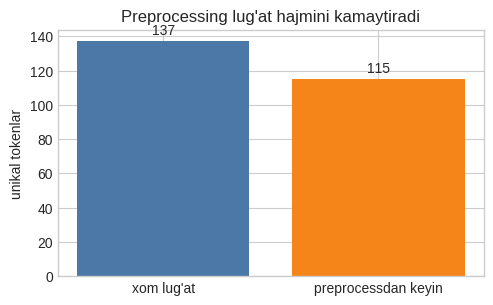

In [54]:
plot_vocab_change(RAW_TEXTS, [preprocess_doc(matn) for matn in RAW_TEXTS])


## 6. So'zlar xaltasi (BoW)

BoW har bir hujjatni so'z sanog'i vektoriga aylantiradi. So'z tartibi yo'qoladi, lekin klassik NLP uchun kuchli baseline paydo bo'ladi.

Kichik `toy_corpus` bilan avval qo'lda matritsa quramiz, keyin xuddi shu g'oyani `sklearn` bilan bog'laymiz.

![BoW matritsa konsepti](assets/d02/d02_bow_matrix.png)


In [58]:
import numpy as np
toy_corpus = ["nlp qiziq", "python foydali", "nlp foydali"]
toy_docs = [doc.split() for doc in toy_corpus]
vocab = ["nlp", "qiziq", "python", "foydali"]

def bow_matrix(tokenized_docs: list[list[str]], vocabulary: list[str]) -> np.ndarray:
    # TO‘LDIRING:
    # 1. (#hujjat, #lug'at) o'lchamli nol matritsa yarating
    X = np.zeros((len(tokenized_docs), len(vocabulary)), dtype=int)
    # 2. word_to_col lug'atini yarating
    word_to_col = {word: i for i, word in enumerate(vocabulary)}
    # 3. hujjatlar va tokenlar bo'yicha aylaning
    for row, doc in enumerate(tokenized_docs):
    # 4. mos katak qiymatini bittaga oshiring
        for token in doc:
            if token in word_to_col:
                col = word_to_col[token]
                X[row, col] += 1

    return X
    raise NotImplementedError("bow_matrix() funksiyasini to'ldiring")

X_bow = bow_matrix(toy_docs, vocab)
bow_df = pd.DataFrame(X_bow, index=["D1", "D2", "D3"], columns=vocab)
bow_df

,nlp,qiziq,python,foydali
D1,1,1,0,0
D2,0,0,1,1
D3,1,0,0,1


In [59]:
# Tekshiruv D
expected_bow = np.array([
    [1, 1, 0, 0],
    [0, 0, 1, 1],
    [1, 0, 0, 1],
])
assert np.array_equal(X_bow, expected_bow)
print("Tekshiruv D o'tdi.")

Tekshiruv D o'tdi.


## 7. TF-IDF'ni qo'lda hisoblash

TF-IDF juda ko'p hujjatda uchraydigan so'zlarning og'irligini pasaytiradi, kamroq hujjatda uchraydigan so'zlarning og'irligini oshiradi.

Bu yerda ma'ruzadagi sodda formula bilan ishlaymiz: `IDF(t) = ln(N / df(t))`.

![TF-IDF konsepti](assets/d02/d02_tfidf_concept.png)


In [61]:
def document_frequency(tokenized_docs: list[list[str]], term: str) -> int:
    # term kamida bir marta uchraydigan hujjatlar soni
    count = 0
    for doc in tokenized_docs:
        if term in doc:
            count += 1
    return count
    raise NotImplementedError("document_frequency() funksiyasini to'ldiring")

def idf(tokenized_docs: list[list[str]], term: str) -> float:
    # TO‘LDIRING: ln(N / df) formulasini yozing
    # IDF = ln(N / df)
    N = len(tokenized_docs)
    df = document_frequency(tokenized_docs, term)
    return np.log(N / df)
    raise NotImplementedError("idf() funksiyasini to'ldiring")

def tfidf_matrix(tokenized_docs: list[list[str]], vocabulary: list[str]) -> np.ndarray:
    # TO‘LDIRING:
    # 1. BoW sanog'ini oling
    counts = bow_matrix(tokenized_docs, vocabulary)
    # 2. har bir so'z uchun IDF qiymatini hisoblang
    idf_values = np.array([
        idf(tokenized_docs, word)
        for word in vocabulary
    ])
    # 3. counts * idf_values qaytaring
    return counts * idf_values
    raise NotImplementedError("tfidf_matrix() funksiyasini to'ldiring")

X_tfidf_manual = tfidf_matrix(toy_docs, vocab)
tfidf_df = pd.DataFrame(X_tfidf_manual, index=["D1", "D2", "D3"], columns=vocab)
tfidf_df.round(3)

,nlp,qiziq,python,foydali
D1,0.405,1.099,0.000,0.000
D2,0.000,0.000,1.099,0.405
D3,0.405,0.000,0.000,0.405


In [62]:
# Tekshiruv E — ma'ruza qiymatlari
nlp_d1 = X_tfidf_manual[0, vocab.index("nlp")]
qiziq_d1 = X_tfidf_manual[0, vocab.index("qiziq")]
python_d2 = X_tfidf_manual[1, vocab.index("python")]
foydali_d2 = X_tfidf_manual[1, vocab.index("foydali")]

assert abs(nlp_d1 - 0.4054651081) < 1e-3
assert abs(qiziq_d1 - 1.0986122887) < 1e-3
assert abs(python_d2 - 1.0986122887) < 1e-3
assert abs(foydali_d2 - 0.4054651081) < 1e-3

print("TF-IDF(nlp, D1):     ", round(nlp_d1, 3))
print("TF-IDF(qiziq, D1):   ", round(qiziq_d1, 3))
print("TF-IDF(python, D2):  ", round(python_d2, 3))
print("TF-IDF(foydali, D2): ", round(foydali_d2, 3))
print("Tekshiruv E o'tdi.")

TF-IDF(nlp, D1):      0.405
TF-IDF(qiziq, D1):    1.099
TF-IDF(python, D2):   1.099
TF-IDF(foydali, D2):  0.405
Tekshiruv E o'tdi.


## 8. Qo‘lda hisoblangan qiymatlarni `sklearn` bilan bog‘lash

`CountVectorizer` BoW matritsasini quradi.

`TfidfVectorizer` IDF uchun biroz boshqa konvensiyadan foydalanadi: `smooth_idf=False` bo‘lsa ham IDF ga `+1` qo‘shadi. Shuning uchun ma’ruza formulasiga moslash uchun xom sanoqlarni ayiramiz:

`sklearn TF-IDF = TF × (ln(N/df) + 1)`  
`ma’ruza TF-IDF = sklearn TF-IDF - TF`


In [63]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from IPython.display import display

count_vec = CountVectorizer(vocabulary=vocab)
X_counts_sklearn = count_vec.fit_transform(toy_corpus).toarray()

tfidf_vec = TfidfVectorizer(vocabulary=vocab, smooth_idf=False, norm=None)
X_tfidf_sklearn = tfidf_vec.fit_transform(toy_corpus).toarray()

# sklearn smoothing'siz IDF: ln(N / df) + 1
# Ma'ruzadagi formula: ln(N / df)
X_tfidf_lecture_from_sklearn = X_tfidf_sklearn - X_counts_sklearn

print("CountVectorizer — BoW:")
display(pd.DataFrame(X_counts_sklearn, index=["D1", "D2", "D3"], columns=vocab))

print("TfidfVectorizer — sklearn konvensiyasi, IDF + 1:")
display(pd.DataFrame(X_tfidf_sklearn, index=["D1", "D2", "D3"], columns=vocab).round(3))

print("Ma'ruza formulasiga moslangan TF-IDF:")
display(pd.DataFrame(X_tfidf_lecture_from_sklearn, index=["D1", "D2", "D3"], columns=vocab).round(3))

assert np.allclose(X_tfidf_lecture_from_sklearn, X_tfidf_manual)
print("Qo'lda hisoblangan TF-IDF va sklearn'dan moslangan TF-IDF bir xil.")

CountVectorizer — BoW:


,nlp,qiziq,python,foydali
D1,1,1,0,0
D2,0,0,1,1
D3,1,0,0,1


TfidfVectorizer — sklearn konvensiyasi, IDF + 1:


,nlp,qiziq,python,foydali
D1,1.405,2.099,0.000,0.000
D2,0.000,0.000,2.099,1.405
D3,1.405,0.000,0.000,1.405


Ma'ruza formulasiga moslangan TF-IDF:


,nlp,qiziq,python,foydali
D1,0.405,1.099,0.000,0.000
D2,0.000,0.000,1.099,0.405
D3,0.405,0.000,0.000,0.405


Qo'lda hisoblangan TF-IDF va sklearn'dan moslangan TF-IDF bir xil.


## 8A. `uz_news_mini.txt` bilan BoW/TF-IDF

Qo‘lda hisoblash uchun kichik 3 hujjatli korpus ishlatdik. Endi shu pipeline’ni siz yuborgan 20 satrli mini yangiliklar korpusiga qo‘llaymiz.

Muhim ehtiyot chorasi: biz preprocessingdan keyin tokenlarni bo‘shliq bilan birlashtiramiz. `sklearn` default tokenizatori apostrofli tokenlarni qayta buzmasligi uchun `tokenizer=str.split`, `token_pattern=None`, `lowercase=False` beramiz.


In [ ]:
# RAW_TEXTS -> preprocess -> bo'shliq bilan birlashtirilgan stringlar
processed_corpus = [vectorizer_uchun_birlashtir(matn) for matn in RAW_TEXTS]

# TO‘LDIRING: CountVectorizer va TfidfVectorizer yarating.
# Eslatma: tokenizer=str.split, token_pattern=None, lowercase=False ishlating.
news_count_vec = None
news_tfidf_vec = None

# X_news_bow = news_count_vec.fit_transform(processed_corpus)
# X_news_tfidf = news_tfidf_vec.fit_transform(processed_corpus)

raise NotImplementedError("CountVectorizer/TfidfVectorizer qismini to'ldiring")

news_terms = np.array(news_tfidf_vec.get_feature_names_out())
print("BoW matritsa shakli:", X_news_bow.shape)
print("TF-IDF matritsa shakli:", X_news_tfidf.shape)
print("Lug'atdan 20 ta token:", news_terms[:20].tolist())

assert X_news_tfidf.shape[0] == len(RAW_TEXTS)
assert any(term.startswith("o'zbek") for term in news_terms)
print("Real korpus tekshiruvi o'tdi.")

In [69]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# CountVectorizer
news_count_vec = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

# TfidfVectorizer
news_tfidf_vec = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

# Vektorlash
X_news_bow = news_count_vec.fit_transform(processed_corpus)
X_news_tfidf = news_tfidf_vec.fit_transform(processed_corpus)

news_terms = np.array(news_tfidf_vec.get_feature_names_out())

print("BoW matritsa shakli:", X_news_bow.shape)
print("TF-IDF matritsa shakli:", X_news_tfidf.shape)
print("Lug'atdan 20 ta token:", news_terms[:20].tolist())

assert X_news_tfidf.shape[0] == len(RAW_TEXTS)
assert any(term.startswith("o'zbek") for term in news_terms)

print("Real korpus tekshiruvi o'tdi.")

BoW matritsa shakli: (20, 115)
TF-IDF matritsa shakli: (20, 115)
Lug'atdan 20 ta token: ['adabiyoti', 'agglyutinativ', 'ahamiyat', 'asar', 'avtomatik', 'barqaror', 'ber', 'biridir', 'biznes', "bo'lishi", "bo'ylab", 'bor', 'bozori', 'buyuk', 'dasturiy', 'dasturlari', 'dasturlash', 'davlat', 'dolzarb', 'dunyo']
Real korpus tekshiruvi o'tdi.


In [66]:
processed_corpus = [vectorizer_uchun_birlashtir(matn) for matn in RAW_TEXTS]

In [67]:
X_news_bow = news_count_vec.fit_transform(processed_corpus)

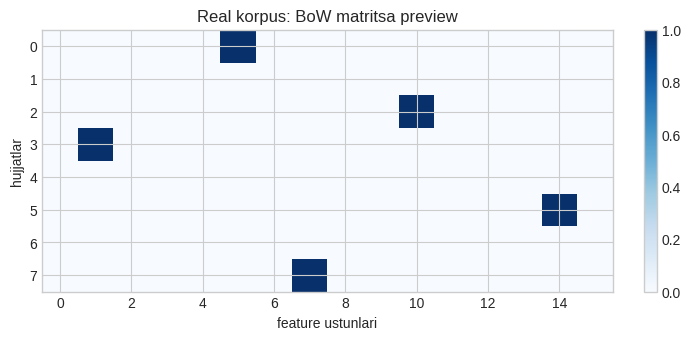

In [70]:
# Vizual tekshiruv: real korpus BoW matritsasining kichik preview'i
plot_matrix_preview(X_news_bow, "Real korpus: BoW matritsa preview")


### Kuzatish

Yuqoridagi jadvalda har bir hujjat uchun TF-IDF bo‘yicha eng kuchli tokenlar chiqadi. Talabalar bilan muhokama qiling: bu tokenlar hujjat mavzusini haqiqatan yaxshi tavsiflayaptimi? Qaysi tokenlar stemming yoki stopword ro‘yxatini yaxshilash zarurligini ko‘rsatmoqda?


,term,tfidf
0,o'zbekiston,0.5311
1,iqtisodiyoti,0.5311
2,rivojlan,0.4668
3,barqaror,0.4668
4,yil,0.0000
5,yondash,0.0000
6,yarat,0.0000
7,yangi,0.0000


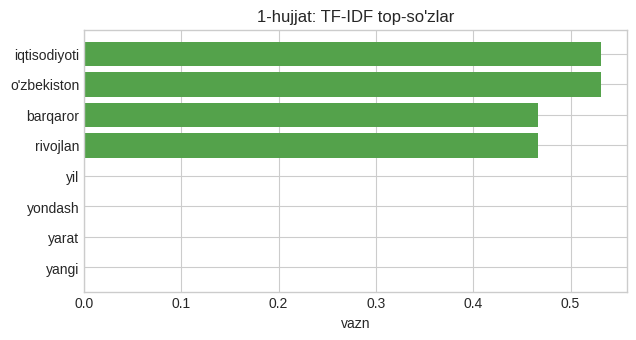

In [71]:
def top_terms_for_doc(doc_index: int, n: int = 6) -> pd.DataFrame:
    row = X_news_tfidf[doc_index].toarray().ravel()
    top_idx = row.argsort()[::-1][:n]
    return pd.DataFrame({
        "term": news_terms[top_idx],
        "tfidf": row[top_idx].round(4),
    })

terms_table = top_terms_for_doc(0, 8)
display(terms_table)
plot_top_terms(terms_table["term"], terms_table["tfidf"], "1-hujjat: TF-IDF top-so'zlar")


## 9. Yengil capstone preview

Bugun capstone arxitekturasini chuqur ochmaymiz. Faqat bitta g'oya: preprocessing funksiyalarini keyingi darslarda qayta ishlatiladigan `TextPreprocessor` klassiga o'rash mumkin.

Kaggle darsida fayl yozish majburiy emas. Quyidagi cell klassni notebook ichida yaratadi; `SAVE_CAPSTONE_MODULE = True` qilsangiz, modul faylga ham saqlanadi.

![TextPreprocessor klassiga o'rash](assets/d02/d02_capstone_wrapper.png)


In [73]:
from __future__ import annotations
from typing import Iterable

SAVE_CAPSTONE_MODULE = False

MODULE_CODE = r'''from __future__ import annotations

import re
from typing import Iterable

APOSTROF_TRANSLATION = str.maketrans({
    "’": "'",
    "‘": "'",
    "ʻ": "'",
    "ʼ": "'",
    "`": "'",
    "´": "'",
})

TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)*")

DEFAULT_STOPWORDS = {
    "va", "yoki", "bu", "ham", "esa", "juda", "bilan", "uchun", "bir",
    "lekin", "ammo", "uch", "har", "barcha", "hali",
    "so'nggi", "yillarda", "bo'lib", "hisoblanadi", "kerak", "muhim", "asosiy",
    "sohasida", "nuqtai", "nazaridan", "qilish", "qilishda",
    "hammaga",
}

DEFAULT_SUFFIXES = (
    "larimizdan", "larimizga", "larimizni",
    "ingizdan", "imizdan", "lardan", "larga", "larni",
    "larida", "laridan", "larimiz", "ingiz", "imiz",
    "moqda", "yapti", "gan", "aman", "amiz", "adi", "dim",
    "ning", "dagi", "ish", "dan", "arli",
    "lar", "lik", "chi", "ga", "ni", "da", "di",
)

class TextPreprocessor:
    def __init__(
        self,
        stopwords: Iterable[str] | None = None,
        suffixes: Iterable[str] | None = None,
        use_stemming: bool = True,
    ) -> None:
        self.stopwords = set(DEFAULT_STOPWORDS if stopwords is None else stopwords)
        self.suffixes = tuple(DEFAULT_SUFFIXES if suffixes is None else suffixes)
        self.use_stemming = use_stemming

    def normalize_apostrophes(self, text: str) -> str:
        return text.translate(APOSTROF_TRANSLATION)

    def tokenize(self, text: str) -> list[str]:
        text = self.normalize_apostrophes(text).lower()
        return TOKEN_RE.findall(text)

    def remove_stopwords(self, tokens: list[str]) -> list[str]:
        return [tok for tok in tokens if tok not in self.stopwords]

    def stem(self, token: str) -> str:
        if not self.use_stemming:
            return token
        for suffix in self.suffixes:
            if token.endswith(suffix):
                stem = token[:-len(suffix)]
                if len(stem) >= 3:
                    return stem
        return token

    def preprocess(self, text: str) -> list[str]:
        tokens = self.tokenize(text)
        tokens = self.remove_stopwords(tokens)
        return [self.stem(tok) for tok in tokens]

    def transform_for_vectorizer(self, text: str) -> str:
        """sklearn vectorizer uchun tokenlarni bo'shliq bilan birlashtirilgan stringga aylantiradi."""
        return " ".join(self.preprocess(text))
'''

# Klassni notebook ichida yaratamiz. Bu Kaggle uchun yetarli.
exec(MODULE_CODE, globals())

if SAVE_CAPSTONE_MODULE:
    MODULE_DIR = Path("capstone/modules")
    MODULE_DIR.mkdir(parents=True, exist_ok=True)
    MODULE_PATH = MODULE_DIR / "m01_text_preprocessor.py"
    MODULE_PATH.write_text(MODULE_CODE, encoding="utf-8")
    print(f"Modul saqlandi: {MODULE_PATH.resolve()}")
else:
    print("TextPreprocessor notebook ichida yaratildi. Faylga saqlash o'tkazib yuborildi.")


TextPreprocessor notebook ichida yaratildi. Faylga saqlash o'tkazib yuborildi.


In [74]:
# Tekshiruv F — TextPreprocessor klassi ishlaydimi?
preprocessor = TextPreprocessor()
assert preprocessor.preprocess("O’zbekistonda NLP o‘rganish juda qiziqarli!") == [
    "o'zbekiston", "nlp", "o'rgan", "qiziq"
]
assert "emas" in preprocessor.preprocess("Bu mahsulot yaxshi emas, qaytarib bering!")

print(preprocessor.preprocess("Mahsulot sifati yaxshi, lekin narxi qimmat."))
print("Tekshiruv F o'tdi.")


['mahsulot', 'sifati', 'yaxshi', 'narxi', 'qimmat']
Tekshiruv F o'tdi.


## 10. Kichik tadqiqot: stemming lug‘at hajmini kamaytiradimi?

Keyingi cell `uz_news_mini.txt` korpusidagi barcha hujjatlar bo‘yicha stemming bor/yo‘q holatlarni solishtiradi.  
So‘ng javob bering: **nega bu ayniqsa o‘zbek tili uchun muhim?**


Stemmingsiz lug'at hajmi: 121
['adabiyotida', 'agglyutinativ', 'ahamiyat', 'asarlar', 'avtomatik', 'barqaror', 'beradi', 'biridir', 'biznes', "bo'lishi", "bo'ylab", 'bormoqda', 'bozori', 'buyuk', 'dasturiy', 'dasturlari', 'dasturlash', 'davlatning', 'dolzarb', 'dunyo', "e'tibor", 'elektron', 'etadi', 'fan', 'faol', 'foydalanuvchilari', 'ilm', 'ilmiy', 'innovatsiyalar', 'insoniyatning', 'intellekt', 'internet', 'iqtisodiy', 'iqtisodiyotga', 'iqtisodiyoti', 'ish', 'ishlamoqda', 'ishlash', 'jarayondir', 'kasb', 'katta', 'kelajagi', 'keng', 'kiberhavfsizlik', "ko'plab", 'kompyuter', 'lingvistikasi', "ma'lumotlarni", 'madaniy', 'mahsulot', 'mamlakatning', 'maqsadlari', 'markazi', 'masalalari', 'matni', 'matnlarni', 'milliy', 'mos', 'muammodir', 'murakkab', 'mutaxassislari', "o'quv", "o'sishning", "o'tish", "o'zbek", "o'zbekiston", 'omillaridan', 'ortib', 'oshirmoqda', 'osonlashtiradi', 'platformalari', 'qabul', 'qaratmoqda', 'qarorlarini', 'qayta', 'qishloq', "qo'shiladi", "qo'shimchalar", 

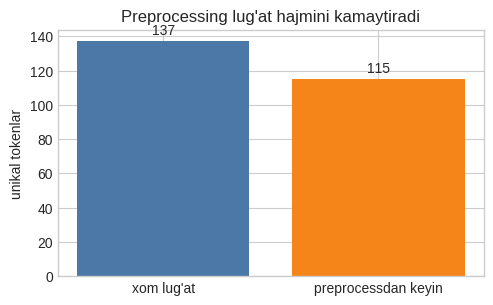

In [75]:
stem_yoq = TextPreprocessor(use_stemming=False)
stem_bor = TextPreprocessor(use_stemming=True)

vocab_stemsiz = sorted({tok for matn in RAW_TEXTS for tok in stem_yoq.preprocess(matn)})
vocab_stemli = sorted({tok for matn in RAW_TEXTS for tok in stem_bor.preprocess(matn)})

print("Stemmingsiz lug'at hajmi:", len(vocab_stemsiz))
print(vocab_stemsiz)
print()
print("Stemming bilan lug'at hajmi:", len(vocab_stemli))
print(vocab_stemli)

plot_vocab_change(RAW_TEXTS, [stem_bor.preprocess(matn) for matn in RAW_TEXTS])


## Chiqish savollari — 5 daqiqa

3–5 gapda javob yozing:

1. O‘zbek apostrof variantlarini e’tiborsiz qoldirsak, qanday tokenizatsiya xatosi yuz beradi?
2. Nega stemming o‘zbek tili uchun BoW/TF-IDF natijasini yaxshilashi mumkin?
3. Nega sentiment tahlilda `emas` so‘zini odatda stopword sifatida olib tashlamaslik kerak?
4. Qaysi qiymat kattaroq va nima uchun: `TF-IDF(qiziq, D1)` yoki `TF-IDF(nlp, D1)`?

### O‘qituvchi uchun tezkor rubric

- **Tokenizatsiya:** Unicode apostroflar va token bo‘linishi aytilgan.
- **Morfologiya:** o‘zbek qo‘shimchalari/agglutinatsiya va lug‘at portlashi tushuntirilgan.
- **Sentiment:** inkor (`emas`) ma’noni o‘zgartirishi aytilgan.
- **TF-IDF:** kam uchraydigan so‘zning IDF qiymati kattaroq bo‘lishi tushuntirilgan.
